In [14]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import sys
from pathlib import Path
import random
import numpy as np
import os
import json

# Make sure src is importable
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root / 'src'))
from etc.hamiltonian import Hamiltonian
from etc_utils.phase_diagrams import *

### First we define utils to build the study graphs

Graph visualization 

In [40]:
def plot_min_h_example(G, k, seed=42, title=None, layout="kamada_kawai"):
    Hobj = Hamiltonian(G)
    mu = Hobj.mu_density_aware(G)
    gamma = Hobj.gamma_balancer(mu=mu)
    Hmin, min_nodes = sample_k_closest_to_zero(
        H=Hobj,
        k=int(k),
        mu=mu,
        gamma=gamma,
        A=Hobj.A,
        D2=Hobj.Dinv2_triu,
        seed=seed,
    )
    min_nodes = sorted(int(x) for x in np.asarray(min_nodes).ravel())

    if layout == "kamada_kawai":
        try:
            pos = nx.kamada_kawai_layout(G)
        except Exception:
            pos = nx.spring_layout(G, seed=seed)
    elif callable(layout):
        pos = layout(G)
    else:
        pos = nx.spring_layout(G, seed=seed)

    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    if title is None:
        title = f"Minimum H example for k={k}"
    ax.set_title(f"{title}\nHmin={Hmin:.6g}")
    ax.axis("off")

    background = [n for n in G.nodes() if n not in min_nodes]

    nx.draw_networkx_edges(G, pos, ax=ax, width=0.4, alpha=0.45, edge_color="#413E3E")
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=background,
        ax=ax,
        node_color="#222121",
        node_size=42,
        linewidths=0,
    )
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=min_nodes,
        ax=ax,
        node_color="#0072B2",
        node_size=120,
        edgecolors="black",
        linewidths=0.7,
    )

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print(f"mu={mu:.6g}, gamma={gamma:.6g}")
    print(f"k={k} minimum H={Hmin:.6g}")
    print(f"Minimizing nodes: {min_nodes}")
    
    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"G_{title}_k{k}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()



    return fig, ax, Hmin, min_nodes, mu, gamma

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=7 minimum H=0.00264617
Minimizing nodes: [7, 9, 12, 13, 17, 18, 30]


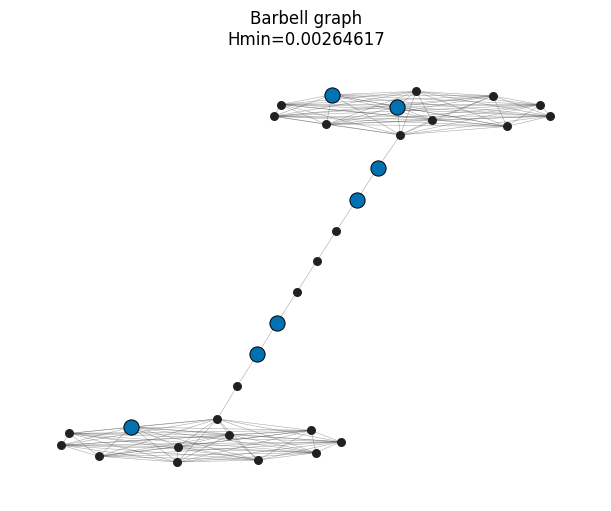

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0.00264617'}>,
 0.0026461693548389675,
 [7, 9, 12, 13, 17, 18, 30],
 0.7157258064516129,
 34.39717741935484)

In [41]:
G = nx.barbell_graph(12, 8)
plot_min_h_example(G, k=7, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=4 minimum H=0
Minimizing nodes: [3, 14, 17, 21]


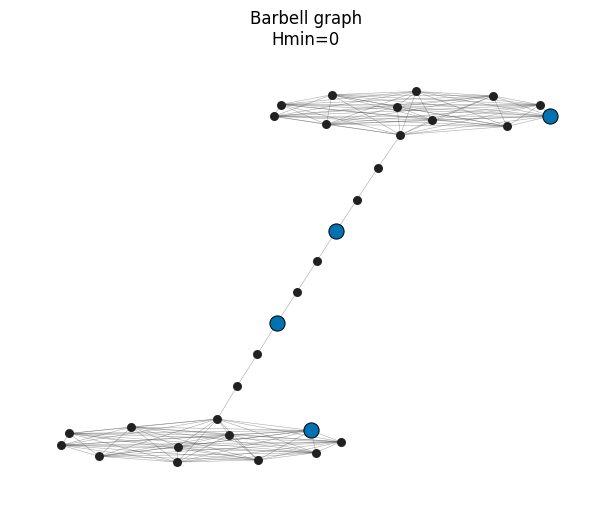

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0'}>,
 0.0,
 [3, 14, 17, 21],
 0.7157258064516129,
 34.39717741935484)

In [ ]:
plot_min_h_example(G, k=4, seed=1, title="Barbell graph")

Graph: n=32, m=141
mu=0.715726, gamma=34.3972
k=5 minimum H=0
Minimizing nodes: [4, 12, 14, 18, 21]


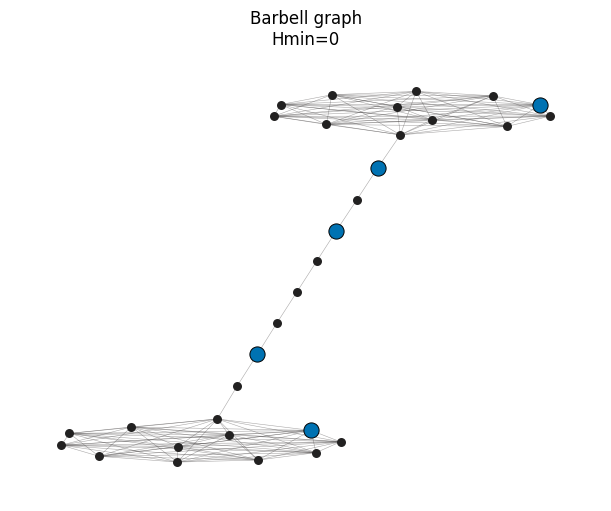

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barbell graph\nHmin=0'}>,
 0.0,
 [4, 12, 14, 18, 21],
 0.7157258064516129,
 34.39717741935484)

In [44]:
plot_min_h_example(G, k=5, seed=2, title="Barbell graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=5 minimum H=0
Minimizing nodes: [79, 104, 129, 132, 143]


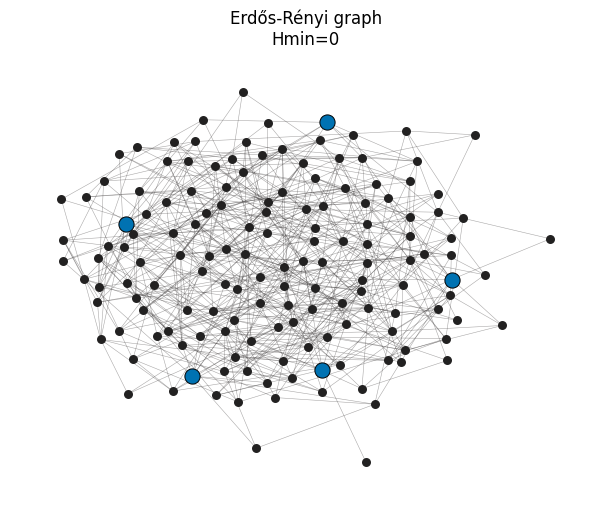

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=0'}>,
 0.0,
 [79, 104, 129, 132, 143],
 0.9459507829977629,
 1.3512304250559286)

In [47]:
G = nx.erdos_renyi_graph(150, 0.05, seed=1)
plot_min_h_example(G, k=5, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=20 minimum H=-2.48571e-06
Minimizing nodes: [1, 2, 3, 4, 6, 10, 11, 12, 16, 19, 28, 29, 33, 34, 43, 44, 52, 57, 101, 125]


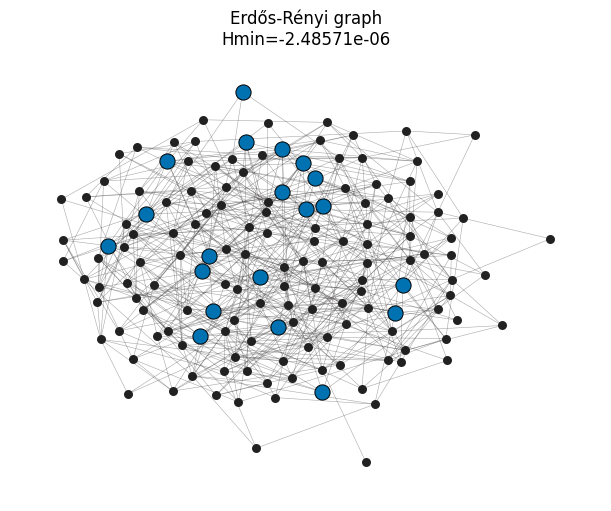

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-2.48571e-06'}>,
 -2.4857071814210485e-06,
 [1, 2, 3, 4, 6, 10, 11, 12, 16, 19, 28, 29, 33, 34, 43, 44, 52, 57, 101, 125],
 0.9459507829977629,
 1.3512304250559286)

In [49]:
plot_min_h_example(G, k=20, seed=2, title="Erdős-Rényi graph")

Graph: n=150, m=604
mu=0.945951, gamma=1.35123
k=10 minimum H=-0.000447427
Minimizing nodes: [3, 9, 25, 32, 33, 70, 86, 118, 121, 126]


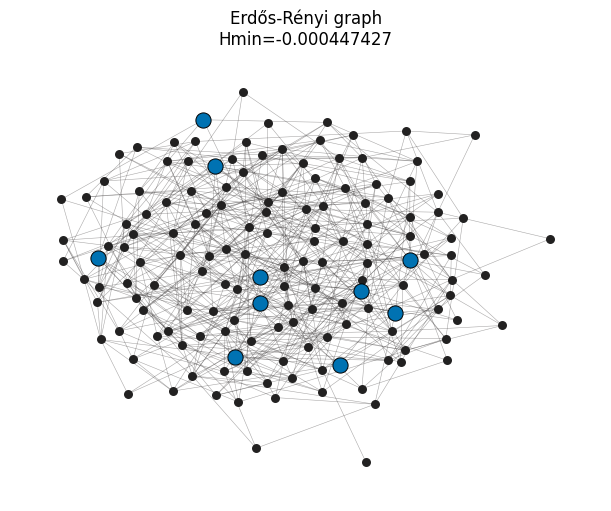

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Erdős-Rényi graph\nHmin=-0.000447427'}>,
 -0.0004474272930643508,
 [3, 9, 25, 32, 33, 70, 86, 118, 121, 126],
 0.9459507829977629,
 1.3512304250559286)

In [50]:
plot_min_h_example(G, k=10, seed=2, title="Erdős-Rényi graph")

In [51]:
G = nx.random_regular_graph(4,150)

Graph: n=150, m=300
mu=0.973154, gamma=1.31544
k=10 minimum H=7.45712e-05
Minimizing nodes: [18, 43, 44, 49, 50, 65, 69, 120, 129, 139]


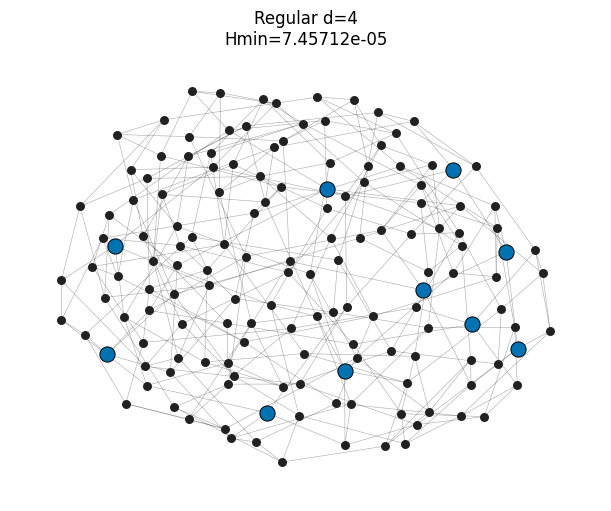

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=7.45712e-05'}>,
 7.45712155110212e-05,
 [18, 43, 44, 49, 50, 65, 69, 120, 129, 139],
 0.9731543624161074,
 1.3154362416107384)

In [52]:
plot_min_h_example(G, k=10, seed=1, title="Regular d=4")

Graph: n=150, m=300
mu=0.973154, gamma=1.31544
k=20 minimum H=-4.47427e-05
Minimizing nodes: [5, 10, 16, 17, 18, 19, 21, 25, 27, 28, 33, 48, 59, 60, 62, 86, 96, 106, 141, 149]


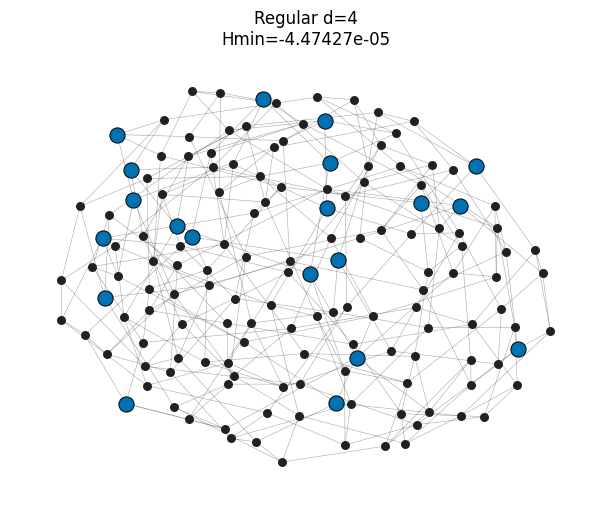

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=-4.47427e-05'}>,
 -4.474272930643508e-05,
 [5,
  10,
  16,
  17,
  18,
  19,
  21,
  25,
  27,
  28,
  33,
  48,
  59,
  60,
  62,
  86,
  96,
  106,
  141,
  149],
 0.9731543624161074,
 1.3154362416107384)

In [53]:
plot_min_h_example(G, k=20, seed=1, title="Regular d=4")

Graph: n=150, m=300
mu=0.973154, gamma=1.31544
k=30 minimum H=0.000253542
Minimizing nodes: [0, 2, 3, 4, 5, 9, 10, 12, 13, 14, 15, 17, 21, 22, 24, 35, 40, 45, 55, 60, 62, 66, 75, 78, 83, 98, 113, 121, 129, 146]


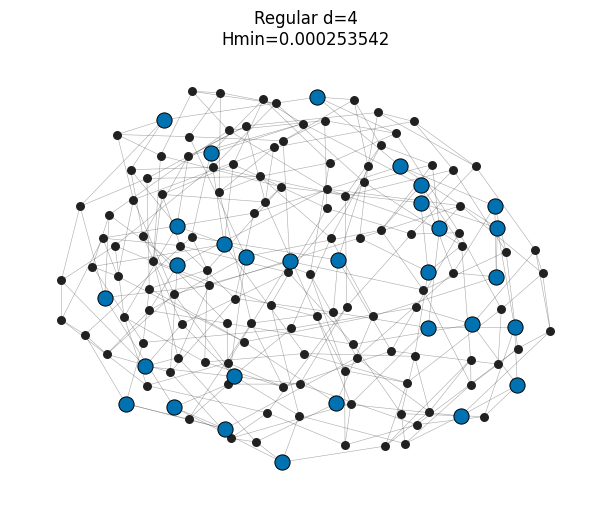

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Regular d=4\nHmin=0.000253542'}>,
 0.00025354213273942605,
 [0,
  2,
  3,
  4,
  5,
  9,
  10,
  12,
  13,
  14,
  15,
  17,
  21,
  22,
  24,
  35,
  40,
  45,
  55,
  60,
  62,
  66,
  75,
  78,
  83,
  98,
  113,
  121,
  129,
  146],
 0.9731543624161074,
 1.3154362416107384)

In [54]:
plot_min_h_example(G, k=30, seed=1, title="Regular d=4")

In [56]:
G = nx.barabasi_albert_graph(n=200, m=4, seed=42)

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=10 minimum H=0.000491346
Minimizing nodes: [4, 13, 42, 56, 96, 98, 112, 128, 171, 197]


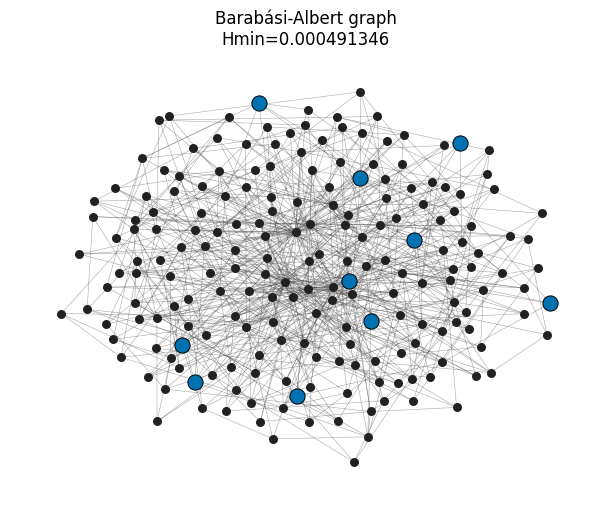

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000491346'}>,
 0.0004913456169735042,
 [4, 13, 42, 56, 96, 98, 112, 128, 171, 197],
 0.9606030150753769,
 0.6303517587939699)

In [57]:
plot_min_h_example(G, k=10, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=20 minimum H=2.23339e-05
Minimizing nodes: [24, 28, 33, 48, 53, 59, 62, 65, 66, 73, 74, 101, 125, 138, 153, 159, 164, 173, 184, 196]


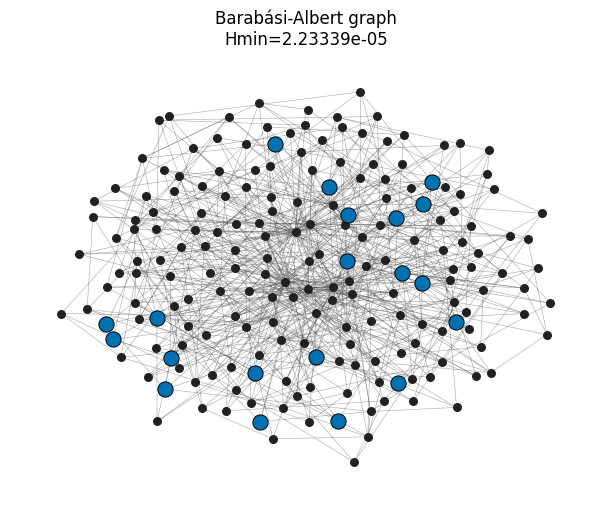

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=2.23339e-05'}>,
 2.2333891680048623e-05,
 [24,
  28,
  33,
  48,
  53,
  59,
  62,
  65,
  66,
  73,
  74,
  101,
  125,
  138,
  153,
  159,
  164,
  173,
  184,
  196],
 0.9606030150753769,
 0.6303517587939699)

In [58]:
plot_min_h_example(G, k=20, seed=1, title="Barabási-Albert graph")

Graph: n=200, m=784
mu=0.960603, gamma=0.630352
k=40 minimum H=0.000111669
Minimizing nodes: [1, 10, 13, 17, 18, 20, 23, 24, 27, 32, 35, 37, 45, 52, 62, 68, 73, 83, 85, 89, 92, 94, 103, 106, 107, 110, 114, 120, 122, 133, 141, 147, 168, 179, 180, 183, 185, 192, 193, 194]


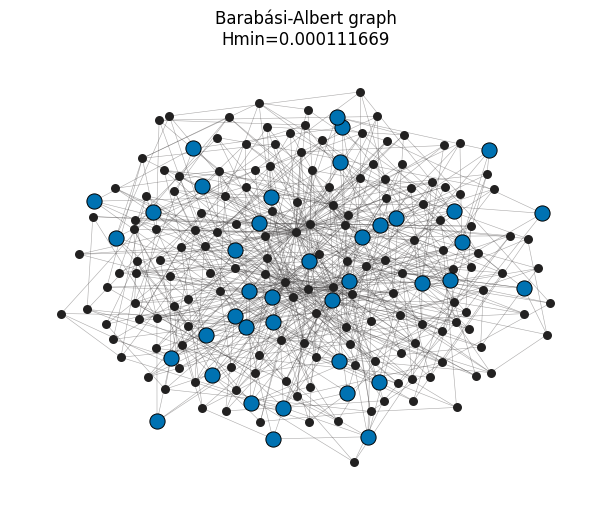

(<Figure size 600x500 with 1 Axes>,
 <Axes: title={'center': 'Barabási-Albert graph\nHmin=0.000111669'}>,
 0.00011166945840557219,
 [1,
  10,
  13,
  17,
  18,
  20,
  23,
  24,
  27,
  32,
  35,
  37,
  45,
  52,
  62,
  68,
  73,
  83,
  85,
  89,
  92,
  94,
  103,
  106,
  107,
  110,
  114,
  120,
  122,
  133,
  141,
  147,
  168,
  179,
  180,
  183,
  185,
  192,
  193,
  194],
 0.9606030150753769,
 0.6303517587939699)

In [61]:
plot_min_h_example(G, k=40, seed=42, title="Barabási-Albert graph")

Random graph: n=150, m=516
Computed phase diagram for random graph only.


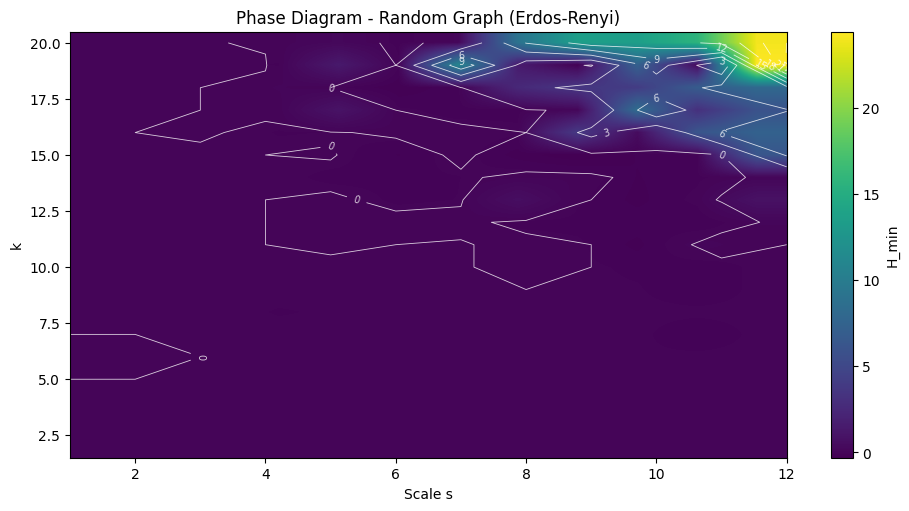

In [62]:
# Phase diagram for only a random graph
seed = 42
G_rand = nx.erdos_renyi_graph(150, 0.05, seed=seed)

H_rand = Hamiltonian(G_rand)
A_rand = np.triu(nx.to_numpy_array(G_rand))
D2_rand = H_rand.Dinv2_triu

random_pd = phase_diagram_values(
    A=A_rand,
    D2=D2_rand,
    Hamiltonian=H_rand,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    scale_steps=1,
    k_steps=1,
)

# Convert dict output to matrix for plotting
k_values = sorted(random_pd.keys())
scale_values = sorted(random_pd[k_values[0]].keys())
hmin_arr = np.array([[random_pd[k][s][1] for s in scale_values] for k in k_values], dtype=float)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
im = ax.imshow(
    hmin_arr,
    aspect="auto",
    origin="lower",
    interpolation="bilinear",
    cmap="viridis",
    extent=[min(scale_values), max(scale_values), min(k_values) - 0.5, max(k_values) + 0.5],
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("H_min")
ax.set_xlabel("Scale s")
ax.set_ylabel("k")
ax.set_title("Phase Diagram - Random Graph (Erdos-Renyi)")

Xc, Yc = np.meshgrid(scale_values, k_values)
cs = ax.contour(Xc, Yc, hmin_arr, levels=8, colors="white", linewidths=0.6, alpha=0.8)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.2g")

print(f"Random graph: n={G_rand.number_of_nodes()}, m={G_rand.number_of_edges()}")
print("Computed phase diagram for random graph only.")
plt.show()